<h1> seaborn.boxplot </h1>

<h1> 1. 결측치 탐색 (Missing Values Exploration)</h1>

박스플롯은 결측치를 직접적으로 탐지하지는 않지만, 결측치가 있는 경우 시각화 전처리 단계에서 결측치 처리가 필요합니다. 
결측치 확인을 위해 isnull() 메서드와 함께 박스플롯을 활용한 데이터 시각화를 진행합니다

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

한글깨짐 과 음수기호 깨짐 방지 설정

In [2]:
plt.rcParams['font.family'] = 'Malgun Gothic'
# 음수 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [3]:
# 데이터 생성
data = {
    "이름": ["Alice", "Bob", "Charlie", "David", "Edward"],
    "수학": [85, 90, np.nan, 75, 100],
    "영어": [88, np.nan, 85, 70, 95]
}
df = pd.DataFrame(data)
df

,이름,수학,영어
0,Alice,85.0,88.0
1,Bob,90.0,NaN
2,Charlie,NaN,85.0
3,David,75.0,70.0
4,Edward,100.0,95.0


In [4]:
# 결측치 확인
print("결측치 탐색 결과:")
print(df.isnull())

결측치 탐색 결과:
      이름     수학     영어
0  False  False  False
1  False  False   True
2  False   True  False
3  False  False  False
4  False  False  False


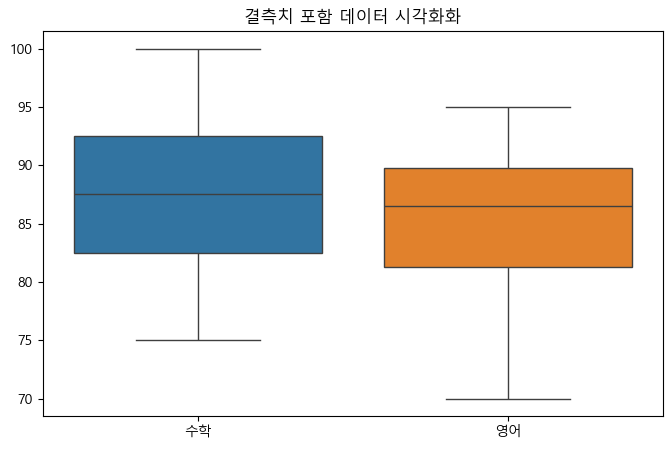

In [5]:

# 박스플롯 시각화

plt.figure(figsize=(8, 5))
plt.title("결측치 포함 데이터 시각화화")

sns.boxplot(data=df[["수학", "영어"]])
plt.show()

<h1> 2. 이상치 탐색 (Outlier Detection)</h1>

seaborn.boxplot() 을 통해 데이터 범위를 벗어난 이상치를 시각적으로 탐색합니다. 
seaborn.boxplot() 의 "수염(whiskers)" 바깥에 있는 점들이 이상치입니다.

 IQR(InterQuartile Range) 방식을 사용할 때 **이상치(Outliers)**는 lower_bound보다 작거나 upper_bound보다 큰 값을 의미합니다. 구체적으로, IQR 방식은 아래와 같은 단계를 통해 이상치를 판별합니다:

1. IQR 계산 공식
Q1 (1st Quartile): 데이터의 25번째 백분위수 값입니다.
Q3 (3rd Quartile): 데이터의 75번째 백분위수 값입니다.

IQR: 𝐼𝑄𝑅 = 𝑄3 −𝑄1
IQR=Q3−Q1 (데이터의 중간 50% 범위)


2. 이상치 기준값
이상치를 판단하기 위한 경계값을 다음과 같이 계산합니다:

Lower Bound (하한): 
𝑄1 − 1.5 × 𝐼𝑄𝑅

Upper Bound (상한): 
𝑄3 + 1.5 × 𝐼𝑄𝑅


3. 이상치 탐지
다음 조건 중 하나를 만족하면 이상치로 간주합니다:

작은 값: 
값 < Lower Bound

큰 값: 
값 > Upper Bound

In [6]:
# 이상치 탐지 데이터 생성
data = {
    "국어": [50, 55, 60, 1000, 65, 70, 75],  # 1000은 이상치
    "과학": [90, 85, 88, 92, 100, 110, 500]  # 500은 이상치
}
df = pd.DataFrame(data)
df

,국어,과학
0,50,90
1,55,85
2,60,88
3,1000,92
4,65,100
5,70,110
6,75,500


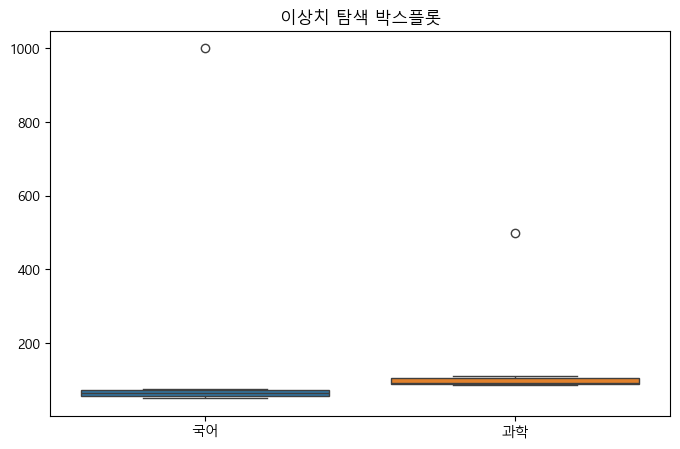

In [7]:
plt.figure(figsize=(8,5))
plt.title("이상치 탐색 박스플롯")

sns.boxplot(data=df)
plt.show()

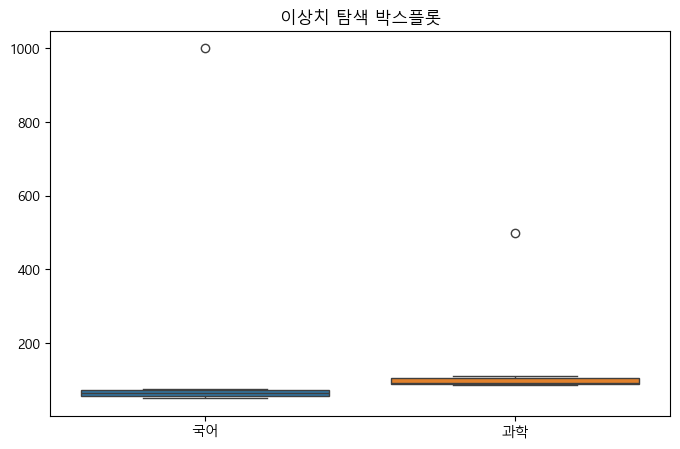

lower_bound 35.0 , upper_bound 95.0
국어의 이상치:
     국어  과학
3  1000  92
lower_bound 65.0 , upper_bound 129.0
과학의 이상치:
   국어   과학
6  75  500


In [8]:
# 박스플롯 시각화
plt.figure(figsize=(8, 5))
sns.boxplot(data=df)
plt.title("이상치 탐색 박스플롯")
plt.show()

# 이상치 확인 (IQR 방식)
for column in df.columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    print(f"lower_bound {lower_bound} , upper_bound {upper_bound}")
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    print(f"{column}의 이상치:")
    print(outliers)


<h1> 3. 불일치 데이터 탐색 (Inconsistent Data Exploration)</h1>

데이터 형식이 일관되지 않거나 규칙을 위반한 데이터를 탐색합니다.
 
예를 들어, 수치형 컬럼에 문자 데이터가 포함된 경우를 탐색합니다.

In [9]:
# 불일치 데이터 생성
data = {
    "이름": ["Alice", "Bob", "Charlie", "David", "Edward"],
    "점수": [85, "결석", 75, 90, 88],  # '결석'은 불일치 데이터
}
df = pd.DataFrame(data)
df

,이름,점수
0,Alice,85
1,Bob,결석
2,Charlie,75
3,David,90
4,Edward,88


불일치 데이터:
    이름  점수
1  Bob  결석


ValueError: Unable to parse string "결석" at position 1

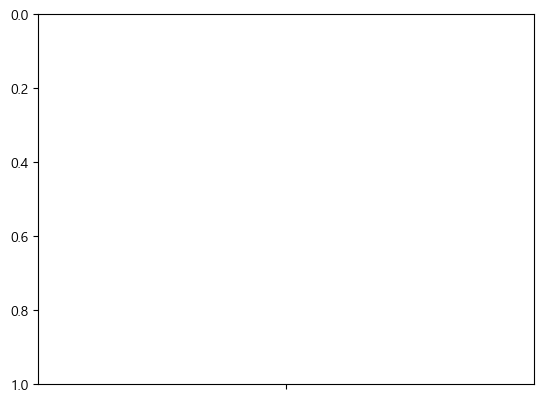

In [10]:
# 데이터 형식 탐지 및 불일치 확인
inconsistent_data = df[~df["점수"].apply(lambda x: isinstance(x, (int, float)))]
print("불일치 데이터:")
print(inconsistent_data)

# 불일치 데이터 박스플롯
sns.boxplot(data=df["점수"])
plt.title("타입 불일치 데이터 박스플롯")
plt.show()

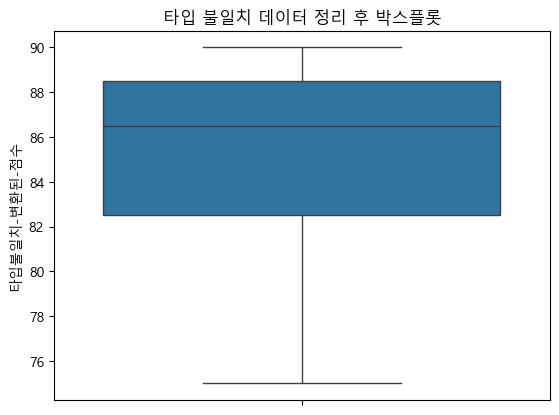

In [ ]:
# 불일치 데이터 박스플롯 (숫자만 시각화)
df["타입불일치-변환된-점수"] = pd.to_numeric(df["점수"], errors="coerce")  # 문자열은 NaN으로 변환
sns.boxplot(data=df["타입불일치-변환된-점수"])
plt.title("타입 불일치 데이터 정리 후 박스플롯")
plt.show()

요약

seaborn.boxplot() 은 분포를 보여주는 그래프이므로, 변수값은 반드시 수치형(numeric) 이어야 합니다.

결측치 탐색: dataframe.isnull()으로 missing value(결측치) 확인후 데이터 시각화를 수행합니다.

이상치 탐색: seaborn.boxplot()의 이상치(IQR 범위를 벗어난)를 IQR 방식으로 탐색합니다.

불일치 데이터 탐색: 데이터 타입 일관성 확인과 문자 또는 오류 값 제거를 병행합니다(pandas.to_numeric(df, errors="coerce"))